$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{January 30, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 1: Introduction to Linear Regression}
\end{array}
$$

# Introduction - (Based on Lec 1 \& 2)

![Linear Regression](../figures/LR_lab1_image1.jpg)

# Simple Linear Regression



---

We cover today's materail in following steps:

1. **Part 1**: What are we even trying to learn? (The DGP mindset)
2. **Part 2**: Random Variables — Discrete vs Continuous
3. **Part 3**: Summarizing Distributions — Expectation & Variance
4. **Part 4**: Two Variables Together — Joint Distributions, Covariance & Correlation
5. **Part 5**: The Best Linear Predictor — What regression *really* is
6. **Part 6**: The Bike Rental Business — Seeing it all in action
7. **Part 7**: Residual Analysis — Understanding what's left over

- Lets code!!

---
# Part 1: What Are We Trying to Learn? 🤔

## The Data Generating Process (DGP)

- When we collect data and run regressions, what are we actually trying to learn about?

1. "We're learning about a population from a sample."

2.  We're learning about the **process** that generated the data — the "rules" the world follows.

### Getting Some intuition

Imagine you're watching someone roll a die. You see: 3, 5, 2, 6, 1, 4, 3, 6...

What are you learning about?
- Not just "these specific rolls"
- You're learning about **the die itself** — is it fair? What's the probability of each face?

The die's properties (the probabilities) existed *before* you saw any rolls. The rolls are just *evidence* about those underlying properties.

### The Statistical Worldview

We treat the world as having an underlying **probability distribution** — a set of rules that determines:
- What outcomes are possible
- How likely each outcome is

This distribution is the **Data Generating Process (DGP)**.


### Why Think This Way?

Thinking about a DGP (rather than just "populations and samples") lets us:

1. **Use probability theory** — a powerful, rigorous toolkit
2. **Make precise statements** about uncertainty
3. **Ask counterfactual questions** — "What would happen if?" (Check out the Causal Inference class)
4. **Apply statistics even when we have full population data**

For regression, our DGP generates (at least) two numerical quantities: **X** and **Y**.

We want to understand how they relate to each other.

---


# Part 2: Random Variables 

## What Makes Something "Random"?

A **random variable** is a quantity whose value is uncertain — it's determined by some probability distribution.

Before you observe it, you don't know exactly what value you'll get. But you *do* know something about the *likelihood* of different values.

### Examples
- The number showing when you roll a die
- Tomorrow's temperature
- A randomly selected person's height
- A student's exam score

### Notation Convention
- **Capital letters** (X, Y) = random variables (uncertain)
- **Lowercase letters** (x, y) = specific realized values (known)

## Discrete Random Variables

**Discrete** random variables take on a finite (or countable) number of distinct values.

### Examples
- Dice rolls: {1, 2, 3, 4, 5, 6}
- Coin flips: {Heads, Tails}
- Number of children: {0, 1, 2, 3, ...}
- Years of college completed: {0, 1, 2, 3, 4}

### Probability Mass Function (PMF)

For discrete random variables, we can ask: **"What's the probability of getting exactly this value?"**

The answer is given by the **PMF**: $P(X = x)$

**Example**: Years of college for students in a course:

| x (years) | P(X = x) |
|-----------|----------|
| 0 | 0.00 |
| 1 | 0.10 |
| 2 | 0.40 |
| 3 | 0.50 |

Notice: The probabilities **add up to 1** (exactly one outcome must occur).

## Continuous Random Variables

**Continuous** random variables take on a continuum of values — infinitely many possibilities in some range.

### Examples
- Height (could be 5.7234... feet)
- Temperature (could be 72.3841...°F)
- Where a spinner lands (0° to 360°)
- Exam scores (if measured precisely)

### The Paradox: P(X = x) = 0

Here's something that trips people up:

> For a continuous random variable, the probability of getting *exactly* any specific value is **zero**.

**Wait, what?** How can everything have probability zero?

### The Spinner Thought Experiment 

Imagine a spinner that can land anywhere from 0° to 360°.

What's the probability it lands at *exactly* 180°?
- Not 180.1°
- Not 180.01°
- Not 180.001°
- But *exactly* 180.000000...°

In a continuous space, any single point is **infinitely small** compared to the whole range. The probability of hitting that exact point is 1/∞ = 0.

### The Solution: Probability Density Functions (PDF)

Instead of asking "what's the probability of exactly x?", we ask:

> **"What's the probability of landing in a *range* of values?"**

This probability equals the **area under the PDF curve** over that range:

$$P(a < X < b) = \int_a^b f(x) \, dx = \text{Area under } f(x) \text{ from } a \text{ to } b$$

The PDF $f(x)$ tells us the **relative likelihood** — where outcomes are more or less concentrated.

## Example: The Uniform Distribution

The simplest continuous distribution: **every value in a range is equally likely**.

### Intuition
Think of the spinner again. If it's perfectly balanced, every angle is equally likely. That's uniform!

### The PDF
For $Y \sim \text{Uniform}[a, b]$:

$$f(y) = \begin{cases} \frac{1}{b-a} & \text{if } a \leq y \leq b \\ 0 & \text{otherwise} \end{cases}$$

**Why 1/(b-a)?** Because the total area must equal 1:
$$\text{Area} = \text{height} \times \text{width} = \frac{1}{b-a} \times (b-a) = 1 \checkmark$$

### Concrete Example: Exam Scores

Suppose exam scores Y are uniform between 60 and 100.

- PDF height = 1/(100-60) = 1/40 = 0.025
- P(score between 90 and 100) = (1/40) × 10 = 1/4 = 25%

Makes sense! The range 90-100 is 1/4 of the full range 60-100.

---
## Let's  Code



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import minimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
%matplotlib inline



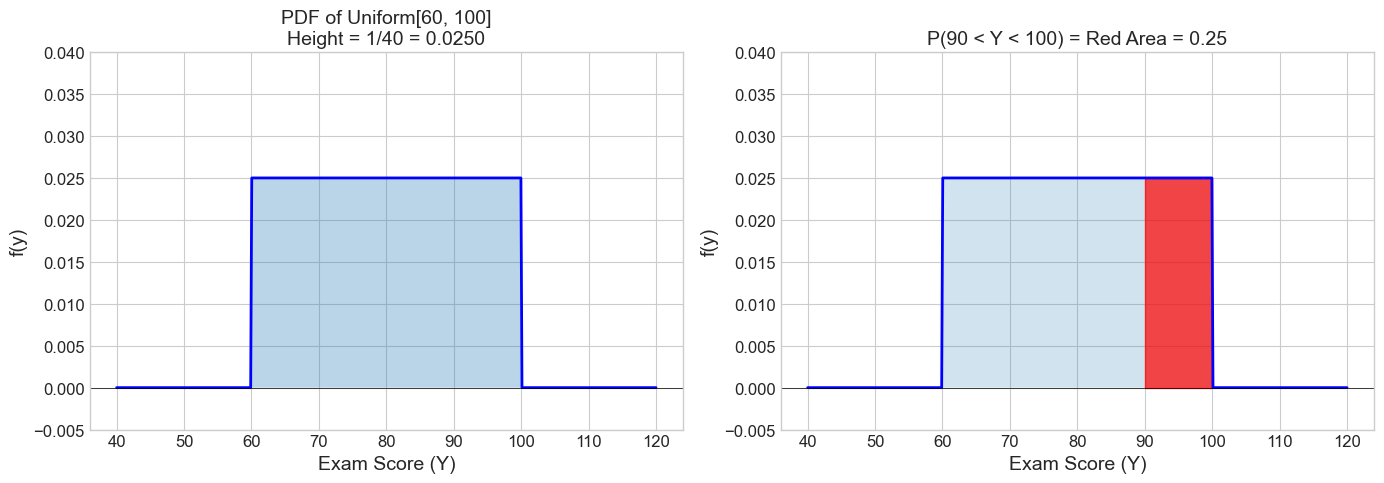

 Verified: P(90 < Y < 100) = 0.2500


In [2]:
# Visualizing the Uniform PDF for exam scores
a, b = 60, 100  # Exam scores between 60 and 100

def uniform_pdf(y, a, b):
    """PDF of Uniform[a, b]"""
    return np.where((y >= a) & (y <= b), 1/(b-a), 0)

y = np.linspace(40, 120, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: The PDF
ax1 = axes[0]
ax1.plot(y, uniform_pdf(y, a, b), 'b-', linewidth=2)
ax1.fill_between(y, uniform_pdf(y, a, b), alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.set_xlabel('Exam Score (Y)', fontsize=14)
ax1.set_ylabel('f(y)', fontsize=14)
ax1.set_title(f'PDF of Uniform[{a}, {b}]\nHeight = 1/{b-a} = {1/(b-a):.4f}', fontsize=14)
ax1.set_ylim(-0.005, 0.04)

# Right: Probability as area
ax2 = axes[1]
ax2.plot(y, uniform_pdf(y, a, b), 'b-', linewidth=2)
ax2.fill_between(y, uniform_pdf(y, a, b), alpha=0.2)
y_range = np.linspace(90, 100, 100)
ax2.fill_between(y_range, uniform_pdf(y_range, a, b), alpha=0.7, color='red')
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.set_xlabel('Exam Score (Y)', fontsize=14)
ax2.set_ylabel('f(y)', fontsize=14)
ax2.set_title('P(90 < Y < 100) = Red Area = 0.25', fontsize=14)
ax2.set_ylim(-0.005, 0.04)

plt.tight_layout()
plt.show()

# Verify with integration
prob, _ = integrate.quad(lambda y: 1/40, 90, 100)
print(f" Verified: P(90 < Y < 100) = {prob:.4f}")

---
# Part 3: Summarizing Distributions 

Distributions can be complex. We need ways to summarize their key features.

## Parameters: Fixed Numbers That Characterize Distributions

A **parameter** is a fixed, non-random number that describes some aspect of a distribution.

>  **Critical Point**: Parameters are **NOT random**. They are fixed properties of the distribution. We might not *know* them, but they don't change.

The regression coefficients β₀ and β₁ are parameters!

## Expectation (Mean): The "Center of Mass"

The **expectation** E[X] is the average value you'd get if you drew from the distribution infinitely many times.

Think of it as the **balance point** of the distribution — if you made a physical model of the PDF and tried to balance it on your finger, E[X] is where it would balance.

### For Discrete RVs
$$E[X] = \sum_{\text{all } x} x \cdot P(X = x)$$

Each value weighted by how likely it is.

### For Continuous RVs
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx$$

Same idea, but integrated.

### Example: Years of College

| x | P(X=x) | x × P(X=x) |
|---|--------|------------|
| 0 | 0.00 | 0.00 |
| 1 | 0.10 | 0.10 |
| 2 | 0.40 | 0.80 |
| 3 | 0.50 | 1.50 |
| **Total** | 1.00 | **2.40** |

E[X] = 2.4 years

### Key Properties 

1. **Linearity**: $E[a + bX] = a + bE[X]$
2. **Additivity**: $E[X + Y] = E[X] + E[Y]$ 
3. **Constants**: $E[a] = a$ 

## Variance: How Spread Out Is It?

The **variance** measures how far values typically are from the mean.

$$\text{Var}(X) = E[(X - E[X])^2]$$

Read this as: "The average squared distance from the mean."

### Why Squared?

1. **Can't just average distances**: Some are positive, some negative — they'd cancel out!
2. **Absolute value works but is hard to work with mathematically**
3. **Squaring**: Always positive, mathematically convenient, penalizes large deviations more

### Alternative Formula (Very Useful!)

$$\text{Var}(X) = E[X^2] - (E[X])^2$$

"Mean of the square minus square of the mean"

### Standard Deviation

Variance is in "squared units" (awkward). Standard deviation fixes this:

$$\sigma_X = \sqrt{\text{Var}(X)}$$

Same units as X — easier to interpret.

In [3]:
# Computing E[Y] and Var(Y) for Y ~ Uniform[60, 100]

a, b = 60, 100

# For Uniform[a,b]:
# E[Y] = (a + b) / 2
# Var(Y) = (b - a)² / 12

E_Y = (a + b) / 2
Var_Y = (b - a)**2 / 12
Std_Y = np.sqrt(Var_Y)

print("EXAM SCORES: Y ~ Uniform[60, 100]")
print("=" * 40)
print(f"E[Y] = (60 + 100) / 2 = {E_Y}")
print(f"Var(Y) = (100-60)² / 12 = {Var_Y:.2f}")
print(f"Std(Y) = √{Var_Y:.2f} = {Std_Y:.2f}")

# Verify with numerical integration
E_Y_num, _ = integrate.quad(lambda y: y * (1/40), 60, 100)
E_Y2_num, _ = integrate.quad(lambda y: y**2 * (1/40), 60, 100)
Var_Y_num = E_Y2_num - E_Y_num**2

print(f"\n Numerical verification:")
print(f"   E[Y] = {E_Y_num:.2f}")
print(f"   Var(Y) = E[Y²] - E[Y]² = {E_Y2_num:.2f} - {E_Y_num**2:.2f} = {Var_Y_num:.2f}")

EXAM SCORES: Y ~ Uniform[60, 100]
E[Y] = (60 + 100) / 2 = 80.0
Var(Y) = (100-60)² / 12 = 133.33
Std(Y) = √133.33 = 11.55

 Numerical verification:
   E[Y] = 80.00
   Var(Y) = E[Y²] - E[Y]² = 6533.33 - 6400.00 = 133.33


---
# Part 4: Two Variables Together 

So far we've talked about single random variables. But regression is about **relationships between two variables**.

## Joint Distributions


When two random variables **occur together**, they have a **joint distribution** that tells us the likelihood of combinations.

### What Does "Occur Together" Mean?

The variables must be defined for the same units/observations:

 **(Temperature, Bike Rentals)** — both measured on the same day  
 **(Years of College, Exam Score)** — both for the same student  
 **(Height, Weight)** — both for the same person  

 **(Your height, Random stranger's weight)** — different people, don't naturally co-occur

### The Joint PDF/PMF

- For discrete: $P(X = x, Y = y)$ — probability of both happening
- For continuous: $f(x, y)$ — density at point (x, y)

The joint distribution encodes **everything** about how X and Y relate!

## Covariance: Do They Move Together?


**Covariance** measures whether two variables tend to move in the same direction.

$$\text{Cov}(X, Y) = E[(X - E[X])(Y - E[Y])]$$

Think about what this formula says:

- When X is above its mean AND Y is above its mean → product is **positive**
- When X is below its mean AND Y is below its mean → product is **positive**
- When one is above and one is below → product is **negative**

### Interpreting the Sign

| Cov(X,Y) | Interpretation |
|----------|----------------|
| **Positive** | X high → Y tends to be high (move together) |
| **Negative** | X high → Y tends to be low (move opposite) |
| **Zero** | No linear relationship |

### Alternative Formula

$$\text{Cov}(X, Y) = E[XY] - E[X]E[Y]$$

### The Problem with Covariance

Covariance depends on the **units** of X and Y.

- Cov(height in cm, weight in kg) will be different from Cov(height in inches, weight in lbs)
- Hard to compare across different variable pairs
- Hard to say if a covariance of 50 is "big" or "small"

We need a standardized measure.

## Correlation: Standardized Covariance

### The Idea

**Correlation** fixes the units problem by dividing by the standard deviations:

$$\rho_{X,Y} = \text{Corr}(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

This is also called the **Pearson correlation coefficient**.

### Why This Works

Dividing by the standard deviations:
1. **Removes the units** — correlation is dimensionless
2. **Bounds the value** — correlation is always between -1 and +1
3. **Makes comparisons meaningful** — 0.8 is "strong" regardless of the variables

### Interpreting Correlation

| Value | Interpretation |
|-------|----------------|
| ρ = +1 | Perfect positive linear relationship |
| ρ = +0.7 to +0.9 | Strong positive relationship |
| ρ = +0.3 to +0.7 | Moderate positive relationship |
| ρ = -0.3 to +0.3 | Weak or no linear relationship |
| ρ = -0.7 to -0.3 | Moderate negative relationship |
| ρ = -0.9 to -0.7 | Strong negative relationship |
| ρ = -1 | Perfect negative linear relationship |

### Important Caveats

1. **Correlation measures LINEAR relationships only** — can be 0 even if variables are strongly related non-linearly!
2. **Correlation ≠ Causation** — two things can be correlated without one causing the other
3. **Sensitive to outliers** — a few extreme points can dramatically change correlation

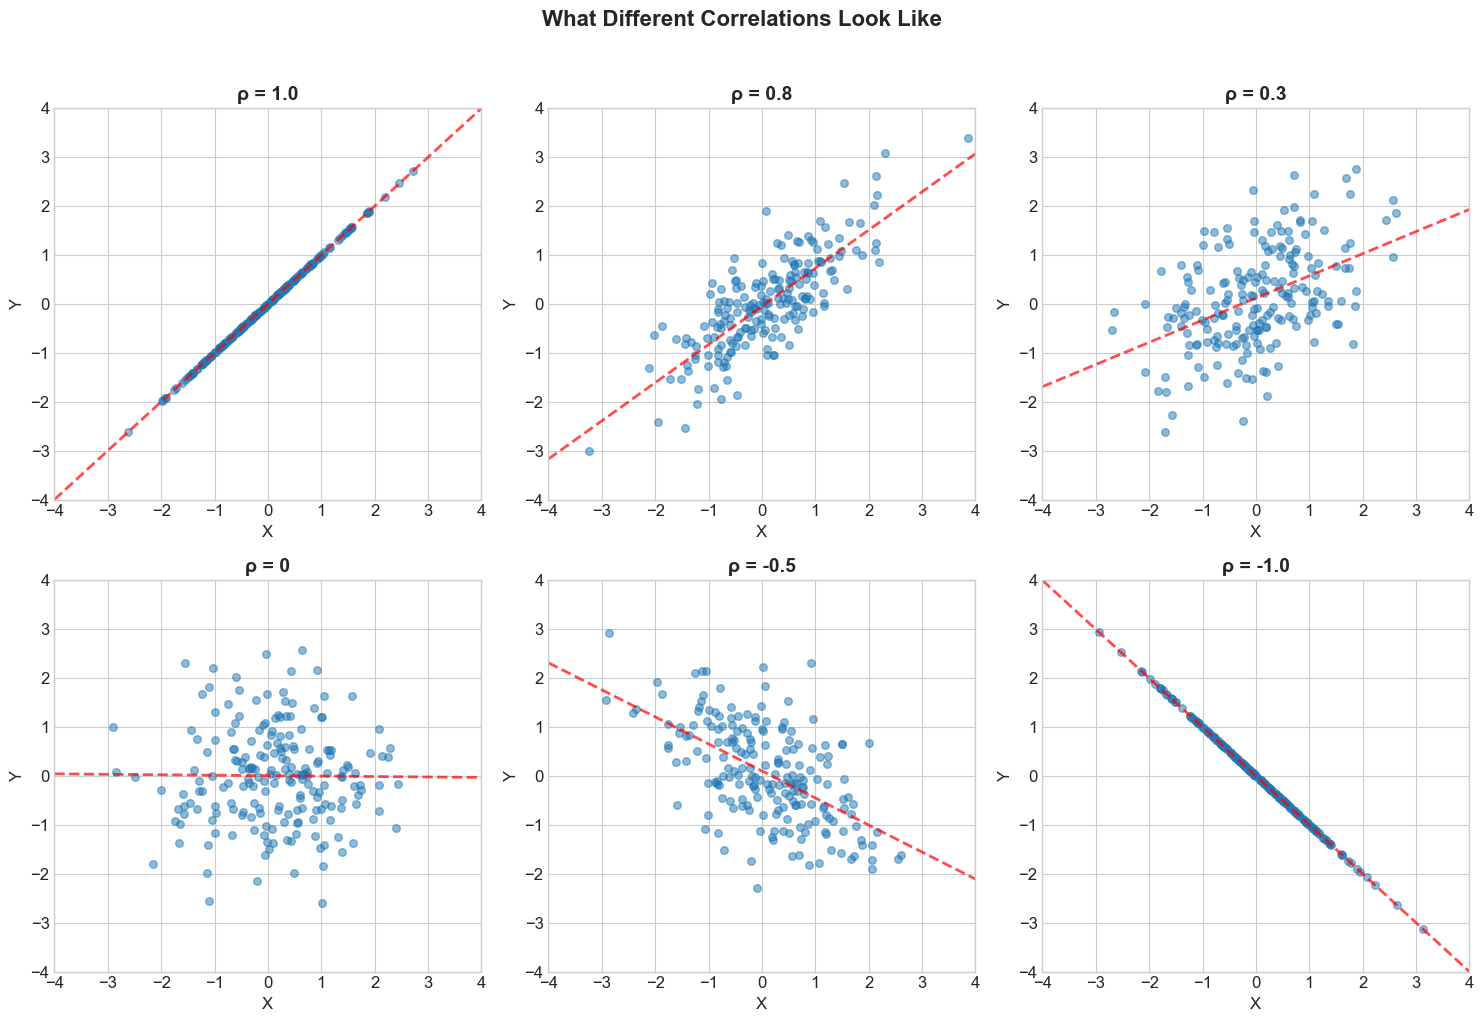

In [4]:
# Visualizing different correlations
np.random.seed(42)

def generate_correlated_data(n, rho):
    """Generate data with specified correlation"""
    x = np.random.normal(0, 1, n)
    y = rho * x + np.sqrt(1 - rho**2) * np.random.normal(0, 1, n)
    return x, y

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
correlations = [1.0, 0.8, 0.3, 0, -0.5, -1.0]

for ax, rho in zip(axes.flat, correlations):
    if abs(rho) == 1:
        x = np.random.normal(0, 1, 200)
        y = rho * x
    else:
        x, y = generate_correlated_data(200, rho)
    
    ax.scatter(x, y, alpha=0.5, s=30)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(f'ρ = {rho}', fontsize=14, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    
    # Add best fit line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot([-4, 4], [p(-4), p(4)], 'r--', linewidth=2, alpha=0.7)

plt.suptitle('What Different Correlations Look Like', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

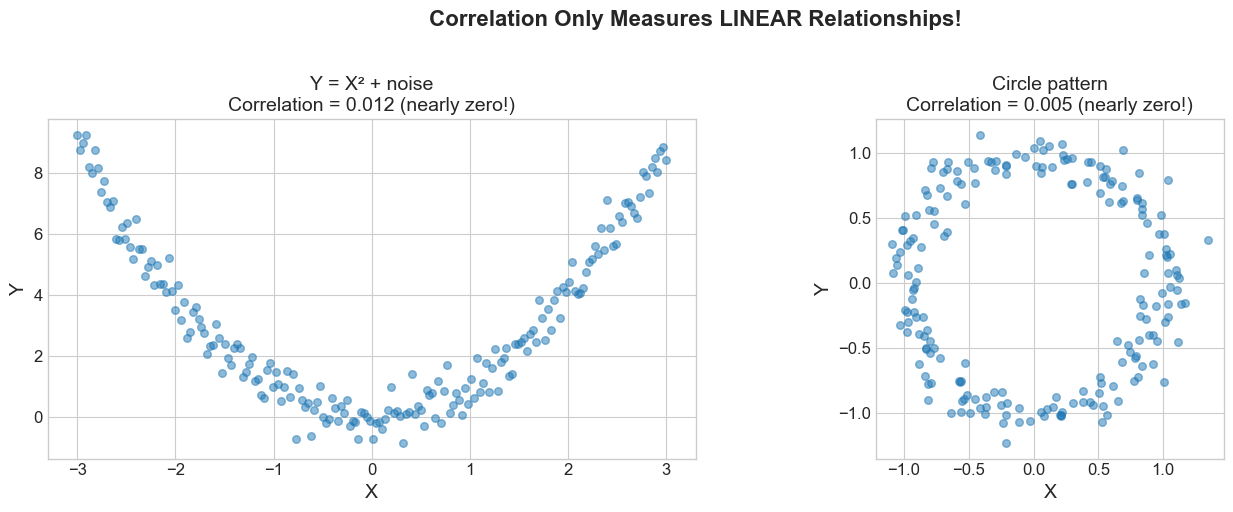

 KEY LESSON: Strong relationship ≠ High correlation
   Correlation only captures LINEAR patterns!


In [5]:
# CRITICAL: Correlation can be zero even with a strong relationship!
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Perfect quadratic relationship
x = np.linspace(-3, 3, 200)
y = x**2 + np.random.normal(0, 0.5, 200)
corr_quad = np.corrcoef(x, y)[0, 1]

axes[0].scatter(x, y, alpha=0.5, s=30)
axes[0].set_xlabel('X', fontsize=14)
axes[0].set_ylabel('Y', fontsize=14)
axes[0].set_title(f'Y = X² + noise\nCorrelation = {corr_quad:.3f} (nearly zero!)', fontsize=14)

# Right: Perfect circular relationship
theta = np.linspace(0, 2*np.pi, 200)
x_circ = np.cos(theta) + np.random.normal(0, 0.1, 200)
y_circ = np.sin(theta) + np.random.normal(0, 0.1, 200)
corr_circ = np.corrcoef(x_circ, y_circ)[0, 1]

axes[1].scatter(x_circ, y_circ, alpha=0.5, s=30)
axes[1].set_xlabel('X', fontsize=14)
axes[1].set_ylabel('Y', fontsize=14)
axes[1].set_title(f'Circle pattern\nCorrelation = {corr_circ:.3f} (nearly zero!)', fontsize=14)
axes[1].set_aspect('equal')

plt.suptitle(' Correlation Only Measures LINEAR Relationships!', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" KEY LESSON: Strong relationship ≠ High correlation")
print("   Correlation only captures LINEAR patterns!")

## Connection to Regression

There's a beautiful relationship between correlation and regression:

$$\beta_1 = \rho_{X,Y} \cdot \frac{\sigma_Y}{\sigma_X}$$

The regression slope is:
- **Correlation** (strength of linear relationship)
- **Times** the ratio of standard deviations (scaling factor)

Also:
$$\beta_1 = \frac{\text{Cov}(X, Y)}{\text{Var}(X)}$$

This tells us: **the slope comes directly from the covariance!**

---
# Part 5: The Best Linear Predictor 

Now we're ready for regression!

## The Prediction Problem

### Setup
You observe X and want to **predict** Y. 

You decide to use a **linear predictor**: $\hat{Y} = b_0 + b_1 X$

### The Question
What values of $b_0$ and $b_1$ make your prediction as good as possible?

### Defining "Good"

We measure prediction quality by **squared error**: $(Y - \hat{Y})^2 = (Y - b_0 - b_1 X)^2$

We want to minimize the **expected** (average) squared error:

$$\boxed{\min_{b_0, b_1} E\left[(Y - b_0 - b_1 X)^2\right]}$$

The values that solve this are **the regression parameters** $\beta_0$ and $\beta_1$.

## What Does "Best Linear Predictor" Mean?

Imagine drawing a scatterplot of (X, Y) pairs.

Now draw **every possible straight line** through that cloud of points.

For each line, measure how far the points are from the line (vertically), square those distances, and average.

The **Best Linear Predictor** is the line with the smallest average squared distance.

### Key Insight

> The BLP is the **best you can do with a straight line**. If the true relationship isn't linear, your predictions won't be perfect — but they'll be as good as any line can get.

## The Residual: What's Left Over

### Definition

The **residual** is the prediction error:

$$\varepsilon \equiv Y - \beta_0 - \beta_1 X$$


The residual captures **everything about Y that X doesn't explain linearly**.

$$Y = \underbrace{\beta_0 + \beta_1 X}_{\text{explained by X}} + \underbrace{\varepsilon}_{\text{everything else}}$$

### Important Points About Residuals

1. **ε is a random variable** — it inherits randomness from Y
2. **ε is "induced by" the regression** — it's defined once we choose to use a linear predictor
3. **ε is NOT something "real" in the world** — it's the gap between reality (Y) and our model (β₀ + β₁X)
4. **(X, Y, ε) form a random vector** — they all co-occur for each observation

### What Goes Into ε?

The residual contains:
- Other factors that affect Y but aren't X
- Non-linear parts of the X-Y relationship
- Measurement error
- Pure randomness

## The Two Golden Conditions

When we solve the minimization problem (using calculus), we get two conditions that the BLP **must** satisfy:

### Condition 1: $E[\varepsilon] = 0$

**Intuition**: The errors average to zero. We're not systematically over- or under-predicting.

### Condition 2: $E[X\varepsilon] = 0$

**Intuition**: The predictor X is uncorrelated with the errors. If X and ε were correlated, we could use that correlation to predict better!

### Why These Matter

These conditions are the foundation of regression theory. They'll come back when we:
- Estimate regression from data
- Think about causality
- Diagnose model problems

## Why Squared Error?

Good question! We could minimize other things:

| Loss Function | Formula | Properties |
|---------------|---------|------------|
| Squared error | $(Y - \hat{Y})^2$ | Differentiable, penalizes large errors heavily |
| Absolute error | $|Y - \hat{Y}|$ | More robust to outliers, but harder math |
| Cubed error | $(Y - \hat{Y})^3$ | Asymmetric — treats over/under differently |

### Why We Usually Use Squared

1. **Mathematically convenient** — derivatives are easy, leads to closed-form solutions
2. **Penalizes large errors** — a prediction off by 10 is "more than twice as bad" as one off by 5
3. **Connection to variance** — minimizing squared error relates to fundamental statistical concepts


---
# Part 6: The Bike Rental Business 🚴

Let's see everything in action with a concrete story!

## The Setup

You own a bike rental company. You want to predict **daily rentals (N)** based on **temperature (T)**.

We'll explore two scenarios:
1. **Bay Area** — pleasant climate, linear relationship
2. **Washington DC** — extreme temperatures hurt rentals, quadratic relationship

## Case 1: Bay Area (Linear World)

### The Story

In the mild Bay Area, warmer = better for biking. Every degree warmer brings more rentals:

$$N = -800 + 20T$$

- At 40°F: N = -800 + 20(40) = 0 rentals (too cold!)
- At 55°F: N = -800 + 20(55) = 300 rentals
- At 70°F: N = -800 + 20(70) = 600 rentals

Temperature varies uniformly between 40°F and 70°F.

### The Question

If we compute the BLP of N given T, what do we get?

### The Answer (Think Before Looking!)

Since the true relationship IS linear, the BLP should recover it exactly:
- $\beta_0 = -800$
- $\beta_1 = 20$

**The BLP of a linear function is that function!**

In [6]:
# Bay Area: Verify that BLP = true function

def N_bay_area(T):
    """True relationship: N = -800 + 20T"""
    return -800 + 20 * T

T_min, T_max = 40, 70

def expected_squared_error(params, N_func, T_min, T_max):
    """Compute E[(N - b0 - b1*T)²] for T ~ Uniform"""
    b0, b1 = params
    def integrand(T):
        N = N_func(T)
        error = N - b0 - b1 * T
        pdf_T = 1 / (T_max - T_min)
        return (error ** 2) * pdf_T
    result, _ = integrate.quad(integrand, T_min, T_max)
    return result

# Find the BLP by minimizing expected squared error
result = minimize(expected_squared_error, [0, 0], 
                  args=(N_bay_area, T_min, T_max), method='Nelder-Mead')
beta_0_bay, beta_1_bay = result.x

print(" BAY AREA RESULTS")
print("=" * 40)
print(f"True function: N = -800 + 20T")
print(f"\nBLP parameters:")
print(f"   β₀ = {beta_0_bay:.2f} (expected: -800)")
print(f"   β₁ = {beta_1_bay:.2f} (expected: 20)")
print(f"\nMinimum expected squared error: {result.fun:.10f}")
print(f"\n Perfect match! The BLP equals the true function.")

 BAY AREA RESULTS
True function: N = -800 + 20T

BLP parameters:
   β₀ = -800.00 (expected: -800)
   β₁ = 20.00 (expected: 20)

Minimum expected squared error: 0.0000000000

 Perfect match! The BLP equals the true function.


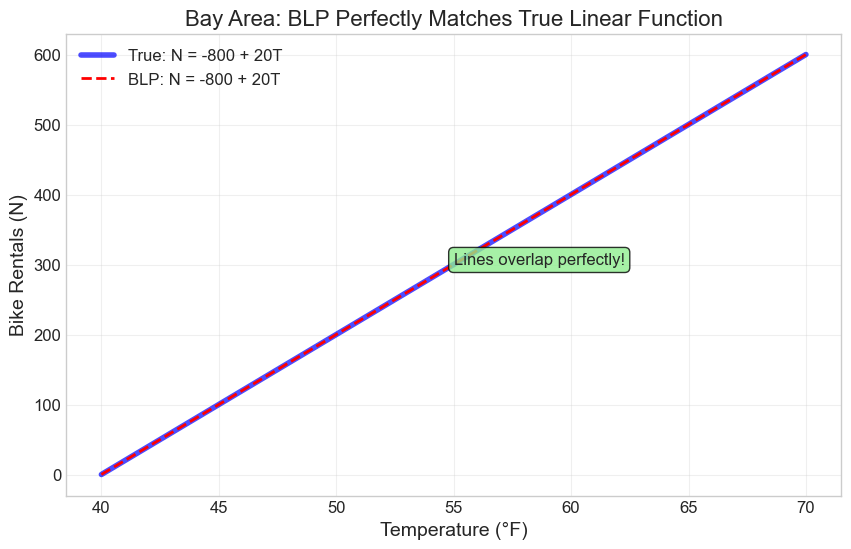

In [7]:
# Visualize Bay Area
T_vals = np.linspace(T_min, T_max, 100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(T_vals, N_bay_area(T_vals), 'b-', linewidth=4, alpha=0.7, label='True: N = -800 + 20T')
ax.plot(T_vals, beta_0_bay + beta_1_bay * T_vals, 'r--', linewidth=2, 
        label=f'BLP: N = {beta_0_bay:.0f} + {beta_1_bay:.0f}T')

ax.set_xlabel('Temperature (°F)', fontsize=14)
ax.set_ylabel('Bike Rentals (N)', fontsize=14)
ax.set_title('Bay Area: BLP Perfectly Matches True Linear Function', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

ax.annotate('Lines overlap perfectly!', xy=(55, 300), fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.show()

##  Case 2: Washington DC (Quadratic World)

### The Story

In DC's extreme climate, BOTH cold AND hot weather hurt rentals. The sweet spot is around 0° (standardized temperature).

$$N = 100 - T^2$$

Where T is standardized temperature, uniform between -10 and +10.

- At T = 0 (perfect weather): N = 100 rentals (maximum!)
- At T = ±5 (somewhat extreme): N = 100 - 25 = 75 rentals
- At T = ±10 (very extreme): N = 100 - 100 = 0 rentals

### The Question

If we try to fit a **linear** predictor to this **quadratic** relationship, what happens?

### Think About It First...

The relationship is symmetric around T = 0:
- Hot (+T) and cold (-T) both reduce rentals equally
- A line that slopes up would over-predict when hot and under-predict when cold (or vice versa)

What slope would minimize average squared error?

**Answer**: A flat line! $\beta_1 = 0$

The best a straight line can do is predict the **average** rental count for everyone.

In [8]:
# DC: Quadratic relationship, linear predictor

def N_dc(T):
    """True relationship: N = 100 - T²"""
    return 100 - T**2

T_min_dc, T_max_dc = -10, 10

# Find BLP
result_dc = minimize(expected_squared_error, [0, 0], 
                     args=(N_dc, T_min_dc, T_max_dc), method='Nelder-Mead')
beta_0_dc, beta_1_dc = result_dc.x

# What's the expected value of T²?
E_T2, _ = integrate.quad(lambda t: t**2 * (1/20), -10, 10)

print(" WASHINGTON DC RESULTS")
print("=" * 40)
print(f"True function: N = 100 - T²")
print(f"\nBLP parameters:")
print(f"   β₀ = {beta_0_dc:.2f}")
print(f"   β₁ = {beta_1_dc:.6f} ≈ 0")
print(f"\n Why β₀ = {beta_0_dc:.2f}?")
print(f"   E[N] = E[100 - T²] = 100 - E[T²] = 100 - {E_T2:.2f} = {100-E_T2:.2f}")
print(f"\n The BLP is just a FLAT LINE!")
print(f"   It predicts ~{beta_0_dc:.0f} rentals regardless of temperature!")

 WASHINGTON DC RESULTS
True function: N = 100 - T²

BLP parameters:
   β₀ = 66.67
   β₁ = 0.000006 ≈ 0

 Why β₀ = 66.67?
   E[N] = E[100 - T²] = 100 - E[T²] = 100 - 33.33 = 66.67

 The BLP is just a FLAT LINE!
   It predicts ~67 rentals regardless of temperature!


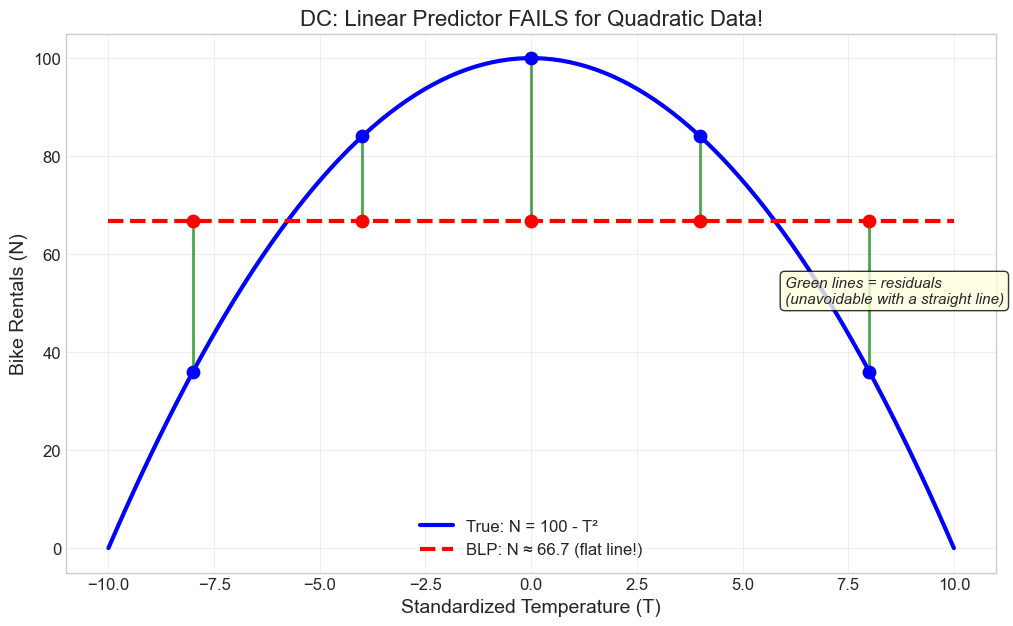

In [9]:
# Visualize DC failure
T_vals_dc = np.linspace(T_min_dc, T_max_dc, 100)

fig, ax = plt.subplots(figsize=(12, 7))

# True quadratic
ax.plot(T_vals_dc, N_dc(T_vals_dc), 'b-', linewidth=3, label='True: N = 100 - T²')

# BLP (flat line)
ax.plot(T_vals_dc, beta_0_dc + beta_1_dc * T_vals_dc, 'r--', linewidth=3, 
        label=f'BLP: N ≈ {beta_0_dc:.1f} (flat line!)')

# Show errors at sample points
sample_T = [-8, -4, 0, 4, 8]
for t in sample_T:
    true_N = N_dc(t)
    pred_N = beta_0_dc
    ax.plot([t, t], [pred_N, true_N], 'g-', linewidth=2, alpha=0.7)
    ax.scatter([t], [true_N], color='blue', s=80, zorder=5)
    ax.scatter([t], [pred_N], color='red', s=80, zorder=5)

ax.set_xlabel('Standardized Temperature (T)', fontsize=14)
ax.set_ylabel('Bike Rentals (N)', fontsize=14)
ax.set_title('DC: Linear Predictor FAILS for Quadratic Data!', fontsize=16)
ax.legend(fontsize=12, loc='lower center')
ax.grid(True, alpha=0.3)

ax.annotate('Green lines = residuals\n(unavoidable with a straight line)', 
            xy=(6, 50), fontsize=11, style='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.show()

##  The Fix: Transform the Predictor!

### The Key Insight

Linear regression is only **"linear in whatever you put in."**

If the true relationship is $N = 100 - T^2$, what if we use $T^2$ as our predictor instead of $T$?

$$N = \beta_0 + \beta_1 \cdot T^2 + \varepsilon$$

This is still "linear regression" (linear in $\beta_1$), but the predictor variable is $T^2$.

### What Should We Get?

If we regress N on $T^2$, we should recover:
- $\beta_0 = 100$
- $\beta_1 = -1$

Because the true relationship is exactly $N = 100 + (-1) \cdot T^2$

In [11]:
# The fix: Use T² as the predictor

def expected_squared_error_T2(params, N_func, T_min, T_max):
    """Compute E[(N - b0 - b1*T²)²]"""
    b0, b1 = params
    def integrand(T):
        N = N_func(T)
        error = N - b0 - b1 * (T**2)  # Note: T² as predictor!
        pdf_T = 1 / (T_max - T_min)
        return (error ** 2) * pdf_T
    result, _ = integrate.quad(integrand, T_min, T_max)
    return result

# Find BLP with T² as predictor
result_T2 = minimize(expected_squared_error_T2, [0, 0], 
                     args=(N_dc, T_min_dc, T_max_dc), method='Nelder-Mead')
beta_0_T2, beta_1_T2 = result_T2.x

print("🔧 THE FIX: USE T² AS PREDICTOR")
print("=" * 40)
print(f"True function: N = 100 - T²")
print(f"\nBLP with T² as predictor:")
print(f"   β₀ = {beta_0_T2:.2f} (expected: 100)")
print(f"   β₁ = {beta_1_T2:.4f} (expected: -1)")
print(f"\nMinimum expected squared error: {result_T2.fun:.10f}")
print(f"\n PERFECT PREDICTION RESTORED!")

🔧 THE FIX: USE T² AS PREDICTOR
True function: N = 100 - T²

BLP with T² as predictor:
   β₀ = 100.00 (expected: 100)
   β₁ = -1.0000 (expected: -1)

Minimum expected squared error: 0.0000000011

 PERFECT PREDICTION RESTORED!


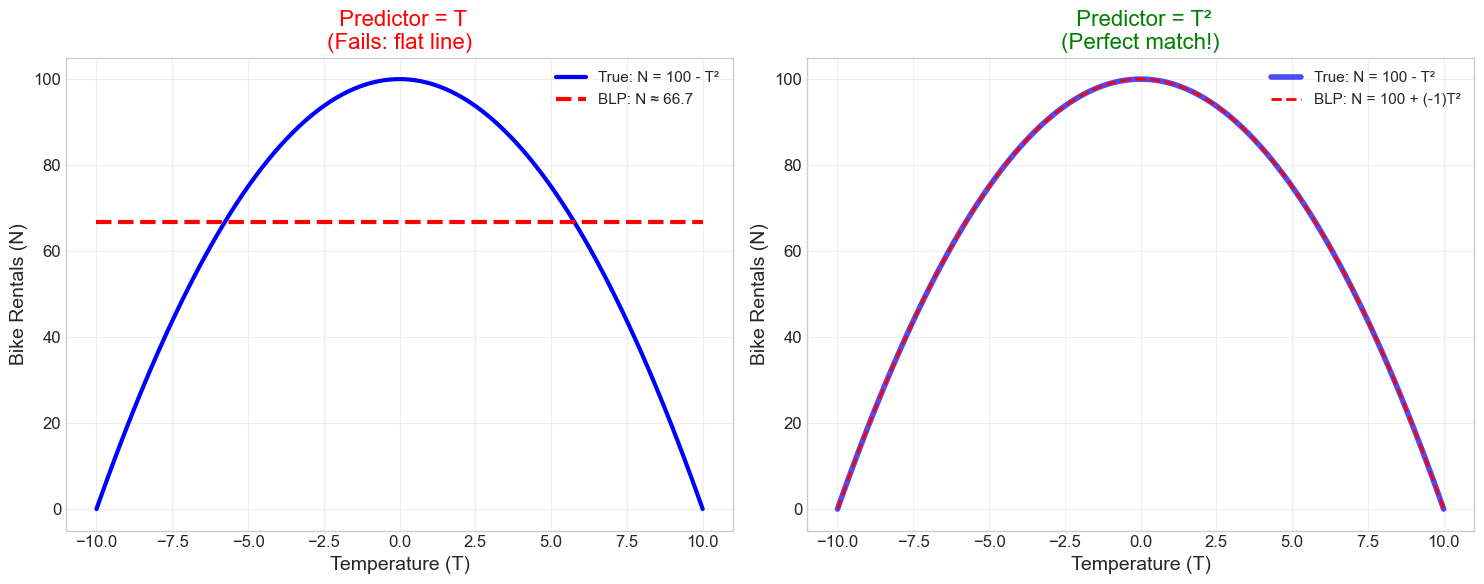

In [12]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Linear in T (fails)
ax1 = axes[0]
ax1.plot(T_vals_dc, N_dc(T_vals_dc), 'b-', linewidth=3, label='True: N = 100 - T²')
ax1.plot(T_vals_dc, beta_0_dc + beta_1_dc * T_vals_dc, 'r--', linewidth=3, 
         label=f'BLP: N ≈ {beta_0_dc:.1f}')
ax1.set_xlabel('Temperature (T)', fontsize=14)
ax1.set_ylabel('Bike Rentals (N)', fontsize=14)
ax1.set_title(' Predictor = T\n(Fails: flat line)', fontsize=16, color='red')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Linear in T² (works!)
ax2 = axes[1]
ax2.plot(T_vals_dc, N_dc(T_vals_dc), 'b-', linewidth=4, alpha=0.7, label='True: N = 100 - T²')
ax2.plot(T_vals_dc, beta_0_T2 + beta_1_T2 * (T_vals_dc**2), 'r--', linewidth=2, 
         label=f'BLP: N = {beta_0_T2:.0f} + ({beta_1_T2:.0f})T²')
ax2.set_xlabel('Temperature (T)', fontsize=14)
ax2.set_ylabel('Bike Rentals (N)', fontsize=14)
ax2.set_title(' Predictor = T²\n(Perfect match!)', fontsize=16, color='green')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 7: Residual Analysis 

Now let's dig deeper into **residuals** — they tell us a lot about how well our model works!

## What Are Residuals Again?

$$\varepsilon_i = Y_i - \hat{Y}_i = Y_i - (\beta_0 + \beta_1 X_i)$$

For each observation, the residual is the vertical distance from the point to the regression line.

## Why Analyze Residuals?

The residuals reveal:
1. **How well the model fits** — small residuals = good fit
2. **Patterns the model misses** — systematic residuals = missing structure
3. **Whether assumptions hold** — residuals should "look random"

## What Should "Good" Residuals Look Like?

If our linear model is appropriate:

1. **E[ε] = 0** — Residuals average to zero (centered at 0)
2. **E[Xε] = 0** — No relationship between X and residuals
3. **Random scatter** — No patterns when plotted against X or Ŷ
4. **Roughly normal** — For inference (optional but helpful)

## Residual Plots: What to Look For

### Residuals vs. X (or Fitted Values)

| Pattern | What It Means |
|---------|---------------|
| Random scatter around 0 |  Model is appropriate |
| Curved pattern |  Missing non-linear relationship |
| Fan shape (wider on one side) |  Non-constant variance (heteroskedasticity) |
| Clusters |  Missing categorical variable |

### Histogram of Residuals

| Pattern | What It Means |
|---------|---------------|
| Centered at 0 |  E[ε] = 0 satisfied |
| Roughly symmetric |  Good for inference |
| Skewed or multi-modal |  May indicate model problems |

In [13]:
# Let's simulate data and analyze residuals!
np.random.seed(42)

# Simulate Bay Area data WITH noise
n_samples = 200
T_samples = np.random.uniform(T_min, T_max, n_samples)
noise = np.random.normal(0, 50, n_samples)  # Add random noise
N_samples = N_bay_area(T_samples) + noise

# Compute sample regression (OLS estimates)
# β₁ = Cov(T, N) / Var(T)
# β₀ = mean(N) - β₁ * mean(T)
cov_TN = np.cov(T_samples, N_samples, ddof=0)[0, 1]
var_T = np.var(T_samples, ddof=0)
beta_1_hat = cov_TN / var_T
beta_0_hat = np.mean(N_samples) - beta_1_hat * np.mean(T_samples)

# Compute fitted values and residuals
N_fitted = beta_0_hat + beta_1_hat * T_samples
residuals = N_samples - N_fitted

print("BAY AREA WITH NOISE: RESIDUAL ANALYSIS")
print("=" * 50)
print(f"Sample size: {n_samples}")
print(f"True: N = -800 + 20T + noise")
print(f"\nEstimated parameters:")
print(f"   β̂₀ = {beta_0_hat:.2f} (true: -800)")
print(f"   β̂₁ = {beta_1_hat:.2f} (true: 20)")
print(f"\nResidual statistics:")
print(f"   Mean of residuals: {np.mean(residuals):.6f} (should be ≈ 0)")
print(f"   Std of residuals: {np.std(residuals):.2f}")
print(f"   Correlation(T, ε): {np.corrcoef(T_samples, residuals)[0,1]:.6f} (should be ≈ 0)")

BAY AREA WITH NOISE: RESIDUAL ANALYSIS
Sample size: 200
True: N = -800 + 20T + noise

Estimated parameters:
   β̂₀ = -789.54 (true: -800)
   β̂₁ = 19.87 (true: 20)

Residual statistics:
   Mean of residuals: -0.000000 (should be ≈ 0)
   Std of residuals: 48.32
   Correlation(T, ε): 0.000000 (should be ≈ 0)


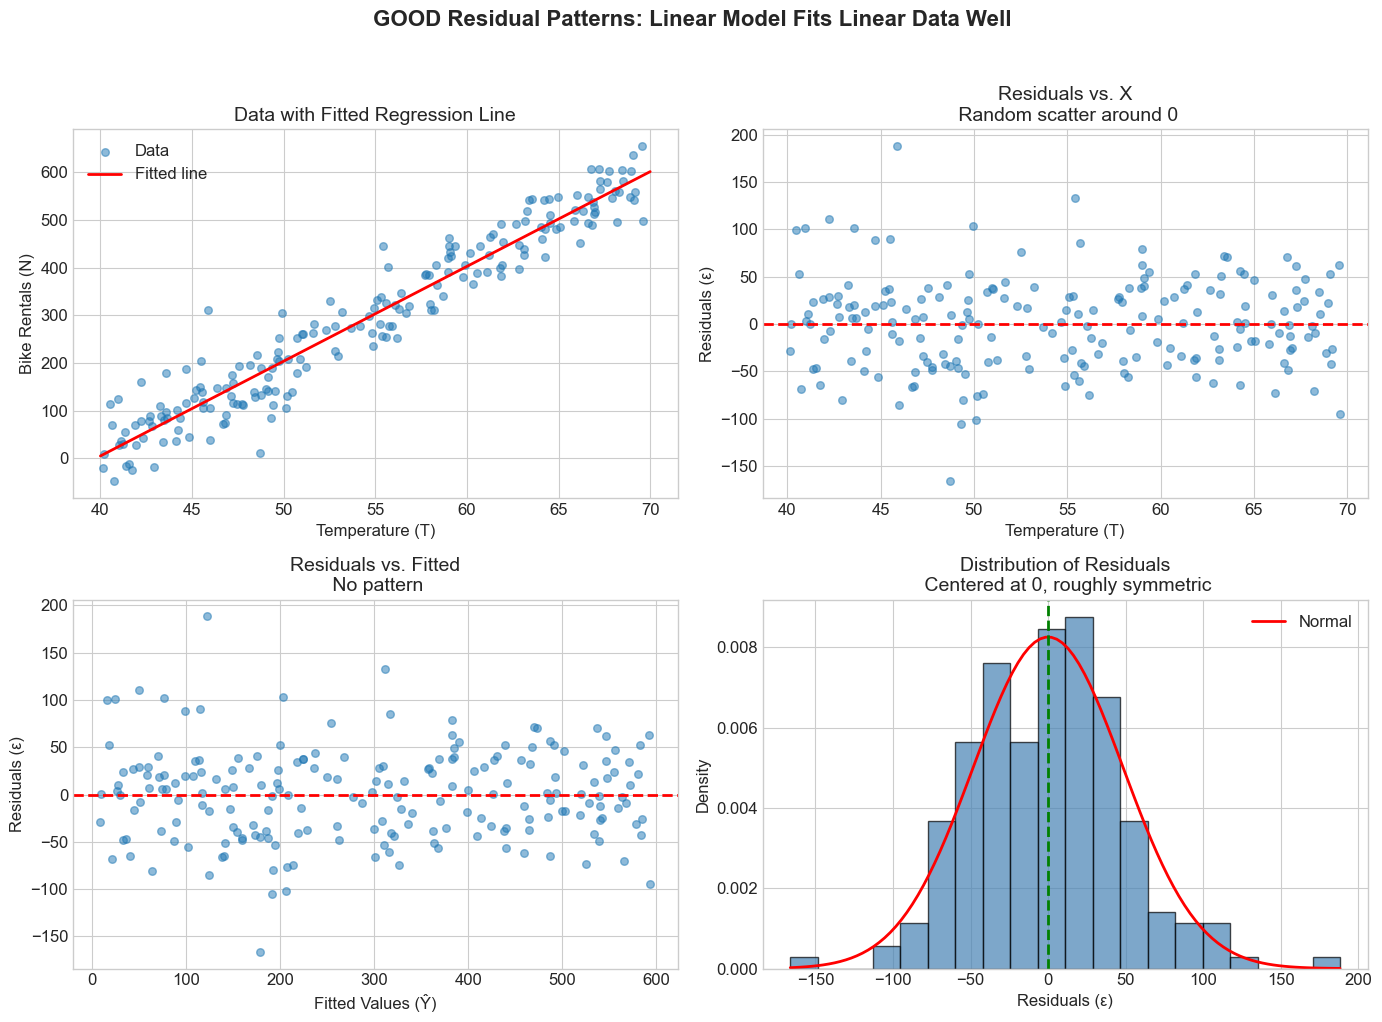

In [14]:
# GOOD residuals: Linear model for linear data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot with regression line
ax1 = axes[0, 0]
ax1.scatter(T_samples, N_samples, alpha=0.5, s=30, label='Data')
T_line = np.linspace(T_min, T_max, 100)
ax1.plot(T_line, beta_0_hat + beta_1_hat * T_line, 'r-', linewidth=2, label='Fitted line')
ax1.set_xlabel('Temperature (T)', fontsize=12)
ax1.set_ylabel('Bike Rentals (N)', fontsize=12)
ax1.set_title('Data with Fitted Regression Line', fontsize=14)
ax1.legend()

# 2. Residuals vs X
ax2 = axes[0, 1]
ax2.scatter(T_samples, residuals, alpha=0.5, s=30)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Temperature (T)', fontsize=12)
ax2.set_ylabel('Residuals (ε)', fontsize=12)
ax2.set_title('Residuals vs. X\n Random scatter around 0', fontsize=14)

# 3. Residuals vs Fitted
ax3 = axes[1, 0]
ax3.scatter(N_fitted, residuals, alpha=0.5, s=30)
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Fitted Values (Ŷ)', fontsize=12)
ax3.set_ylabel('Residuals (ε)', fontsize=12)
ax3.set_title('Residuals vs. Fitted\n No pattern', fontsize=14)

# 4. Histogram of residuals
ax4 = axes[1, 1]
ax4.hist(residuals, bins=20, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# Overlay normal curve
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax4.plot(x_norm, stats.norm.pdf(x_norm, 0, np.std(residuals)), 'r-', linewidth=2, label='Normal')
ax4.axvline(x=0, color='green', linestyle='--', linewidth=2)
ax4.set_xlabel('Residuals (ε)', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Distribution of Residuals\n Centered at 0, roughly symmetric', fontsize=14)
ax4.legend()

plt.suptitle('GOOD Residual Patterns: Linear Model Fits Linear Data Well', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

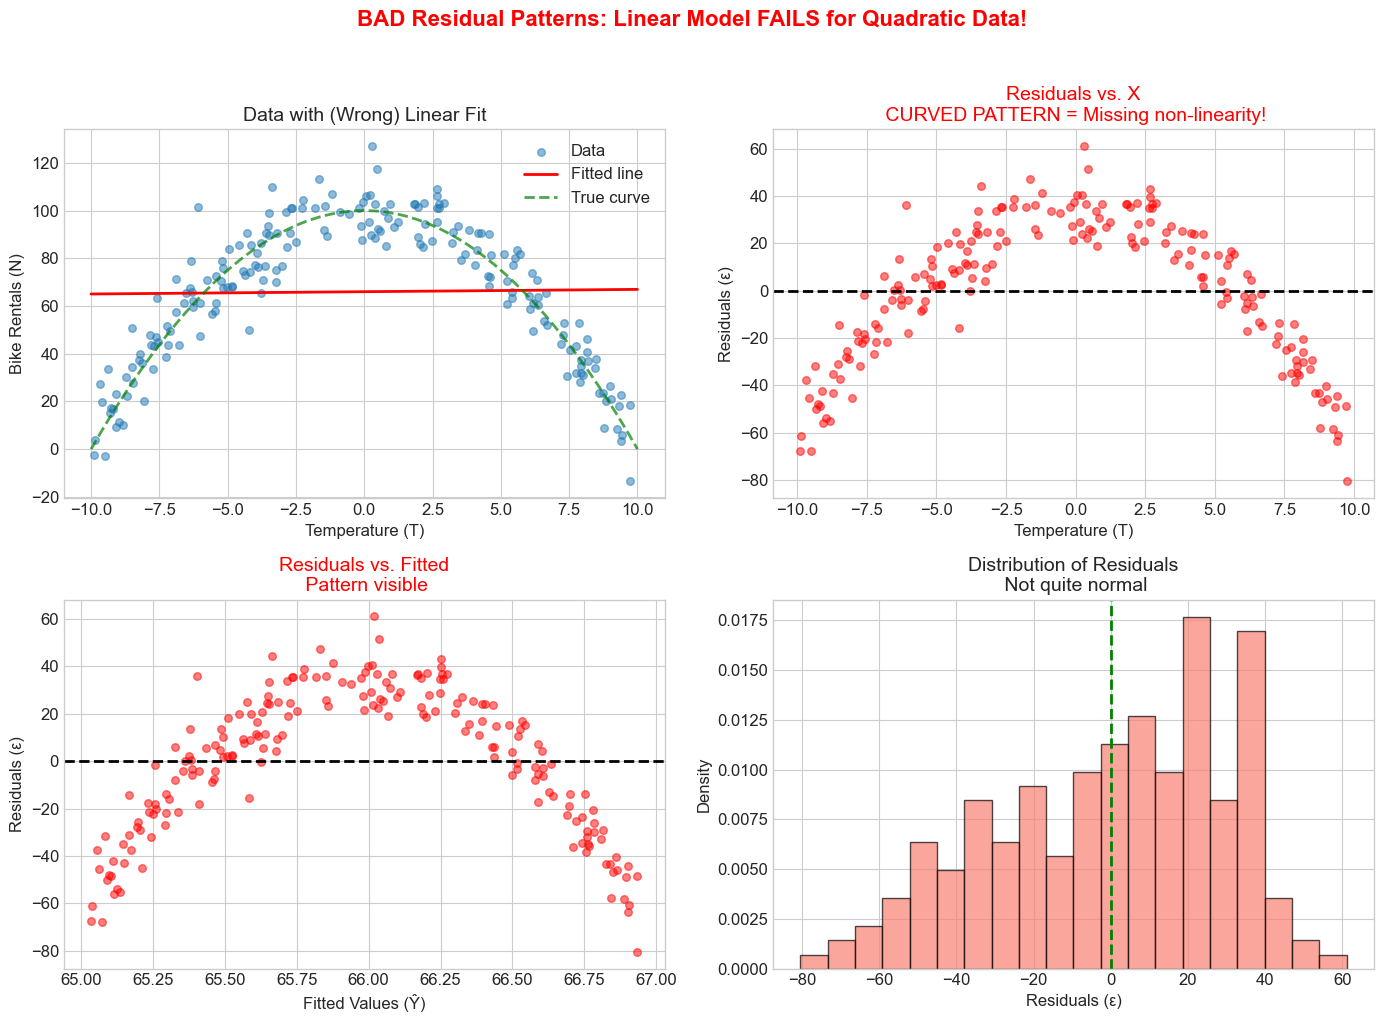


 KEY DIAGNOSTIC: The U-shaped pattern in 'Residuals vs X' tells us
   the linear model is missing a quadratic relationship!


In [15]:
# BAD residuals: Linear model for quadratic data (DC case)
np.random.seed(42)

# Simulate DC data with noise
T_samples_dc = np.random.uniform(T_min_dc, T_max_dc, n_samples)
noise_dc = np.random.normal(0, 10, n_samples)
N_samples_dc = N_dc(T_samples_dc) + noise_dc

# Fit LINEAR model (wrong!)
cov_TN_dc = np.cov(T_samples_dc, N_samples_dc, ddof=0)[0, 1]
var_T_dc = np.var(T_samples_dc, ddof=0)
beta_1_hat_dc = cov_TN_dc / var_T_dc
beta_0_hat_dc = np.mean(N_samples_dc) - beta_1_hat_dc * np.mean(T_samples_dc)

N_fitted_dc = beta_0_hat_dc + beta_1_hat_dc * T_samples_dc
residuals_dc = N_samples_dc - N_fitted_dc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot with (bad) regression line
ax1 = axes[0, 0]
ax1.scatter(T_samples_dc, N_samples_dc, alpha=0.5, s=30, label='Data')
T_line_dc = np.linspace(T_min_dc, T_max_dc, 100)
ax1.plot(T_line_dc, beta_0_hat_dc + beta_1_hat_dc * T_line_dc, 'r-', linewidth=2, label='Fitted line')
ax1.plot(T_line_dc, N_dc(T_line_dc), 'g--', linewidth=2, label='True curve', alpha=0.7)
ax1.set_xlabel('Temperature (T)', fontsize=12)
ax1.set_ylabel('Bike Rentals (N)', fontsize=12)
ax1.set_title('Data with (Wrong) Linear Fit', fontsize=14)
ax1.legend()

# 2. Residuals vs X - THIS SHOWS THE PROBLEM!
ax2 = axes[0, 1]
ax2.scatter(T_samples_dc, residuals_dc, alpha=0.5, s=30, c='red')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_xlabel('Temperature (T)', fontsize=12)
ax2.set_ylabel('Residuals (ε)', fontsize=12)
ax2.set_title('Residuals vs. X\n CURVED PATTERN = Missing non-linearity!', fontsize=14, color='red')

# 3. Residuals vs Fitted
ax3 = axes[1, 0]
ax3.scatter(N_fitted_dc, residuals_dc, alpha=0.5, s=30, c='red')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax3.set_xlabel('Fitted Values (Ŷ)', fontsize=12)
ax3.set_ylabel('Residuals (ε)', fontsize=12)
ax3.set_title('Residuals vs. Fitted\n Pattern visible', fontsize=14, color='red')

# 4. Histogram of residuals
ax4 = axes[1, 1]
ax4.hist(residuals_dc, bins=20, density=True, alpha=0.7, color='salmon', edgecolor='black')
ax4.axvline(x=0, color='green', linestyle='--', linewidth=2)
ax4.set_xlabel('Residuals (ε)', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Distribution of Residuals\n Not quite normal', fontsize=14)

plt.suptitle('BAD Residual Patterns: Linear Model FAILS for Quadratic Data!', fontsize=16, fontweight='bold', color='red', y=1.02)
plt.tight_layout()
plt.show()

print("\n KEY DIAGNOSTIC: The U-shaped pattern in 'Residuals vs X' tells us")
print("   the linear model is missing a quadratic relationship!")

##  Verifying the Golden Conditions

Let's verify that our BLP solutions satisfy $E[\varepsilon] = 0$ and $E[X\varepsilon] = 0$.

In [16]:
def verify_FOCs(N_func, beta_0, beta_1, T_min, T_max, use_T_squared=False):
    """Verify E[ε] = 0 and E[Xε] = 0"""
    pdf_T = 1 / (T_max - T_min)
    
    def epsilon(T):
        N = N_func(T)
        X = T**2 if use_T_squared else T
        return N - beta_0 - beta_1 * X
    
    E_epsilon, _ = integrate.quad(lambda t: epsilon(t) * pdf_T, T_min, T_max)
    
    def X_epsilon(T):
        X = T**2 if use_T_squared else T
        return X * epsilon(T)
    
    E_X_epsilon, _ = integrate.quad(lambda t: X_epsilon(t) * pdf_T, T_min, T_max)
    
    return E_epsilon, E_X_epsilon

print("VERIFYING FIRST-ORDER CONDITIONS")
print("=" * 50)

# Bay Area
E_eps, E_T_eps = verify_FOCs(N_bay_area, beta_0_bay, beta_1_bay, T_min, T_max)
print(f"\n Bay Area (linear predictor, linear data):")
print(f"   E[ε] = {E_eps:.2e} ≈ 0 ✓")
print(f"   E[Tε] = {E_T_eps:.2e} ≈ 0 ✓")

# DC with T
E_eps, E_T_eps = verify_FOCs(N_dc, beta_0_dc, beta_1_dc, T_min_dc, T_max_dc)
print(f"\n DC (linear predictor, quadratic data):")
print(f"   E[ε] = {E_eps:.2e} ≈ 0 ✓")
print(f"   E[Tε] = {E_T_eps:.2e} ≈ 0 ✓")
print(f"   (FOCs satisfied, but fit is poor!)")

# DC with T²
E_eps, E_T2_eps = verify_FOCs(N_dc, beta_0_T2, beta_1_T2, T_min_dc, T_max_dc, use_T_squared=True)
print(f"\n DC (T² predictor, quadratic data):")
print(f"   E[ε] = {E_eps:.2e} ≈ 0 ✓")
print(f"   E[T²ε] = {E_T2_eps:.2e} ≈ 0 ✓")
print(f"   (FOCs satisfied AND perfect fit!)")

VERIFYING FIRST-ORDER CONDITIONS

 Bay Area (linear predictor, linear data):
   E[ε] = 2.01e-06 ≈ 0 ✓
   E[Tε] = 8.82e-05 ≈ 0 ✓

 DC (linear predictor, quadratic data):
   E[ε] = -2.41e-05 ≈ 0 ✓
   E[Tε] = -2.14e-04 ≈ 0 ✓
   (FOCs satisfied, but fit is poor!)

 DC (T² predictor, quadratic data):
   E[ε] = -1.93e-05 ≈ 0 ✓
   E[T²ε] = -1.45e-03 ≈ 0 ✓
   (FOCs satisfied AND perfect fit!)


##  Residual Analysis Summary

| What to Check | How to Check | What to Look For |
|---------------|--------------|------------------|
| E[ε] = 0 | Mean of residuals | Should be ≈ 0 |
| E[Xε] = 0 | Correlation(X, ε) | Should be ≈ 0 |
| Linearity | Residuals vs X plot | No curved pattern |
| Constant variance | Residuals vs Fitted | No fan shape |
| Normality | Histogram of residuals | Roughly bell-shaped |

**If residuals show patterns**: Your model is missing something! Consider:
- Adding transformed predictors (X², log(X), etc.)
- Adding additional predictors
- Using a different model entirely

---
#  Summary: What We Learned

## The Big Ideas

| Concept | Key Insight |
|---------|-------------|
| **DGP** | We model the world as a probability distribution |
| **Random Variables** | Discrete (PMF) vs Continuous (PDF) — for continuous, P(X=x)=0! |
| **Parameters** | Fixed numbers that characterize distributions (NOT random) |
| **Expectation** | The "center of mass" — average over infinite draws |
| **Variance** | How spread out the distribution is |
| **Covariance** | Do two variables move together? (units-dependent) |
| **Correlation** | Standardized covariance, bounded [-1, +1] |
| **BLP** | The line that minimizes expected squared prediction error |
| **FOCs** | E[ε]=0 and E[Xε]=0 — residuals average to zero and are uncorrelated with X |
| **Residual Analysis** | Check for patterns — they reveal model problems |

## The Bike Rental Lessons

1. **Linear data → Linear BLP works perfectly** (Bay Area)
2. **Non-linear data → Linear BLP does its best but misses structure** (DC with T)
3. **Transform the predictor → Can capture non-linearity** (DC with T²)
4. **Residual plots reveal the problem** — curved residuals = missing non-linearity

## The Golden Rules

> **Linear regression is only "linear" in the predictor variable you choose.**  
> By transforming your predictor, you can capture non-linear relationships.

> **Always check your residuals!**  
> They tell you if your model is missing important structure.